In [136]:
import sys
import os

#sys.path.insert(0, os.path.abspath('..'))
import photospline

from icecube import dataio, icetray, dataclasses, simclasses
import numpy.random as random
import numpy as np
import scipy.optimize as optimize
import matplotlib.pyplot as plt
#from scripts.SplineEval import evalLogPdf


In [137]:
two_D_ary = np.array([])
for i in range(501):
    if i < 10:
        runnumber = '00' + str(i)
    elif i < 100:
        runnumber = '0' + str(i)
    else:
        runnumber = str(i)
    if os.path.isfile(f'/mnt/scratch/dillonb5/2d_logL/delta_ary_{runnumber}.npy'):
        #print(runnumber)
        ary = np.load(f'/mnt/scratch/dillonb5/2d_logL/delta_ary_{runnumber}.npy')
    
        mask = ary != 0
        ary_masked = ary[mask]
        two_D_ary = np.concatenate((two_D_ary, ary_masked))

print(two_D_ary)

[  3.46494317 339.62392735   1.8478725  ...   2.07821798   5.04077959
   9.36126637]


In [138]:
three_D_ary = np.array([])
for i in range(501):
    if i < 10:
        runnumber = '00' + str(i)
    elif i < 100:
        runnumber = '0' + str(i)
    else:
        runnumber = str(i)
    if os.path.isfile(f'/mnt/scratch/dillonb5/3d_logL/delta_ary_{runnumber}.npy'):
        #print(runnumber)
        ary = np.load(f'/mnt/scratch/dillonb5/3d_logL/delta_ary_{runnumber}.npy')
    
        mask = ary != 0
        ary_masked = ary[mask]
        three_D_ary = np.concatenate((three_D_ary, ary_masked))

print(three_D_ary)

[  1.83172131  11.         412.96348178 ...   3.69030142   2.6641202
   7.27377534]


In [139]:
print(len(three_D_ary))
print(len(two_D_ary))

22063
19469


In [140]:
print(f'Two Dimensional Spline:')
print(f'Mean: {np.mean(two_D_ary)}')
print(f'Median: {np.median(two_D_ary)}')
print(f'Standard Deviation: {np.std(two_D_ary)}')
print()
print()
print('Three Dimensional Spline:')
print(f'Mean: {np.mean(three_D_ary)}')
print(f'Median: {np.median(three_D_ary)}')
print(f'Standard Deviation: {np.std(three_D_ary)}')

Two Dimensional Spline:
Mean: 21576.2054558026
Median: 115.07430958747864
Standard Deviation: 589172.7124866841


Three Dimensional Spline:
Mean: 4887.789206432124
Median: 78.0
Standard Deviation: 222434.39927813926


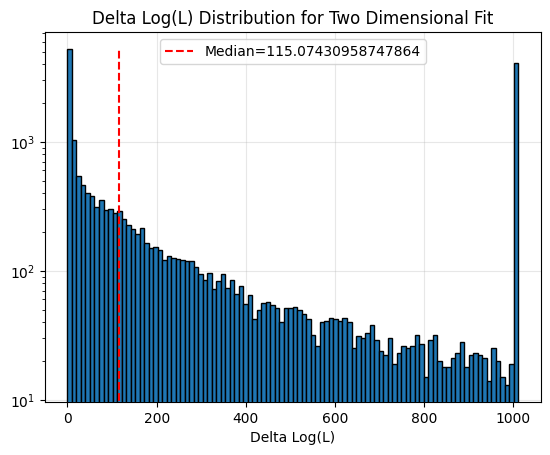

In [141]:
bin_edges = np.append(np.linspace(0, 1001, 100), max(two_D_ary))
#bins_linear = np.linspace(0, 300, bin_edges)

hist, edges = np.histogram(two_D_ary, bin_edges)
#plt.figure(figsize=(10,7))
plt.grid(alpha = 0.3, zorder = 0)
plt.bar(edges[:-1], hist, width = edges[1] - edges[0], ec = 'black', align='edge', zorder = 3)
plt.vlines(np.median(two_D_ary), 0, max(hist), colors='red', ls='--', zorder=5, label=f'Median={np.median(two_D_ary)}')
#plt.xticks(edges[:-1])
plt.title('Delta Log(L) Distribution for Two Dimensional Fit')
plt.yscale('log')
plt.legend()
plt.xlabel('Delta Log(L)')
plt.savefig('../plots/2d_deltalogL_plt.png')

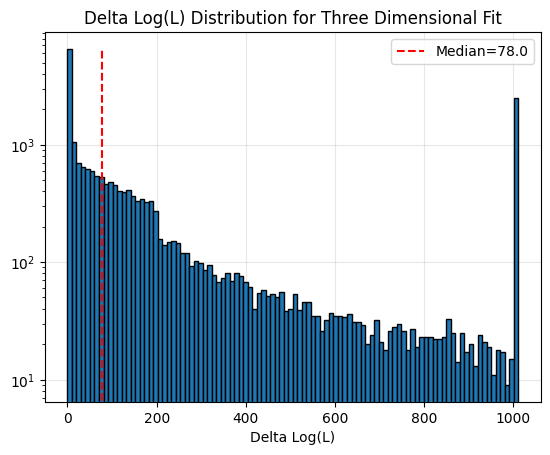

In [142]:
bin_edges = np.append(np.linspace(0, 1001, 100), max(three_D_ary))
#bins_linear = np.linspace(0, 300, bin_edges)

hist, edges = np.histogram(three_D_ary, bin_edges)
#plt.figure(figsize=(10,7))
plt.grid(alpha = 0.3, zorder = 0)
plt.bar(edges[:-1], hist, width = edges[1] - edges[0], ec = 'black', align='edge', zorder = 3)
plt.vlines(np.median(three_D_ary), 0, max(hist), colors='red', ls='--', zorder=5, label=f'Median={np.median(three_D_ary)}')
#plt.xticks(edges[:-1])
plt.title('Delta Log(L) Distribution for Three Dimensional Fit')
plt.legend()
plt.yscale('log')
plt.xlabel('Delta Log(L)')
plt.savefig('../plots/3d_deltalogL_plt.png')

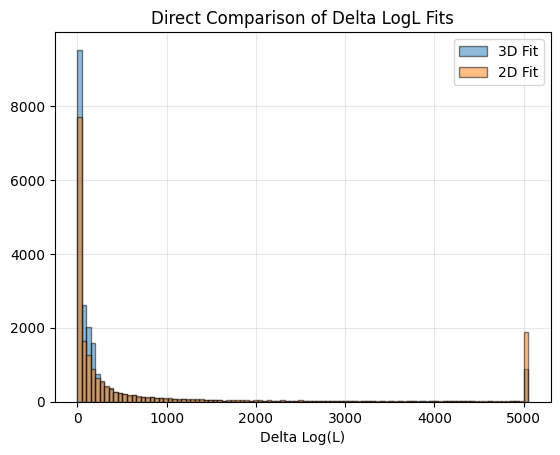

In [143]:
bin_edges = np.append(np.linspace(0, 5001, 100), max(two_D_ary))
#bins_linear = np.linspace(0, 300, bin_edges)

hist1, edges = np.histogram(three_D_ary, bin_edges)
hist2, edges=np.histogram(two_D_ary, bin_edges)
#plt.figure(figsize=(10,7))
plt.grid(alpha = 0.3, zorder = 0)
plt.bar(edges[:-1], hist1, width = edges[1] - edges[0], ec = 'black', align='edge', zorder = 3, alpha=0.5, label="3D Fit")
plt.bar(edges[:-1], hist2, width = edges[1] - edges[0], ec = 'black', align='edge', zorder = 3, alpha=0.5, label="2D Fit")

#plt.vlines(np.median(three_D_ary), 0, max(hist), colors='red', ls='--', zorder=5, label=f'Median={np.median(three_D_ary)}')
#plt.xticks(edges[:-1])
plt.title('Direct Comparison of Delta LogL Fits')
plt.legend()
#plt.yscale('log')
plt.xlabel('Delta Log(L)')
plt.savefig('../plots/overlay_plt_lin.png')

In [144]:
ary_list = []
for i in range(101):
    if i < 10:
        runnumber = '00' + str(i)
    elif i < 100:
        runnumber = '0' + str(i)
    else:
        runnumber = str(i)
    if os.path.isfile(f'/mnt/scratch/dillonb5/sampled_logL_3d/delta_ary_{runnumber}.npy'):
        #print(runnumber)
        ary = np.load(f'/mnt/scratch/dillonb5/sampled_logL_3d/delta_ary_{runnumber}.npy')
        
        
        ary_list.append(ary)
        #sampled_3d = np.vstack(ary_list)

for ary in ary_list:
    if ary.shape == (0,):
        ary_list.remove(ary)

new_list = np.vstack(ary_list)  
sampled_3d = new_list[:,0]  
n_hits = new_list[:,1]

/tmp/ipykernel_1003383/2115501124.py:19: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  ary_list.remove(ary)


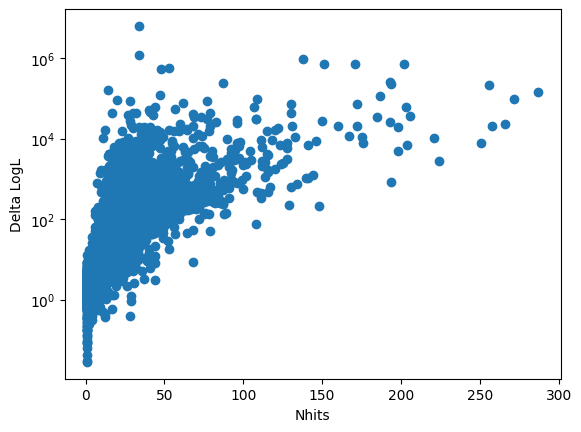

In [149]:
plt.scatter(n_hits, sampled_3d)
plt.xlabel('Nhits')
plt.ylabel('Delta LogL')
plt.yscale('log')

In [146]:
np.median(sampled_3d)

69.75847053527832

Text(0.5, 0, 'Delta Log(L)')

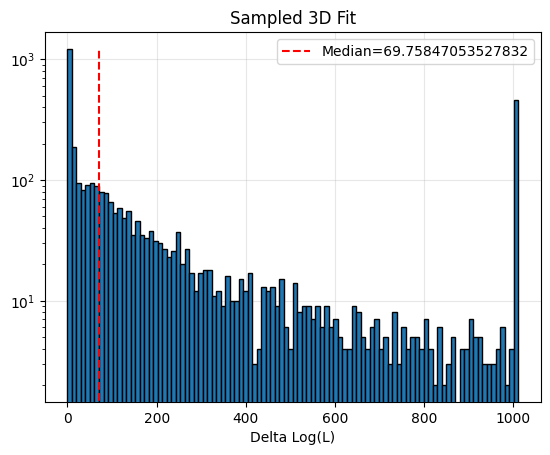

In [147]:
bin_edges = np.append(np.linspace(0, 1001, 100), max(sampled_3d))
#bins_linear = np.linspace(0, 300, bin_edges)

hist, edges = np.histogram(sampled_3d, bin_edges)
#plt.figure(figsize=(10,7))
plt.grid(alpha = 0.3, zorder = 0)
plt.bar(edges[:-1], hist, width = edges[1] - edges[0], ec = 'black', align='edge', zorder = 3)
plt.vlines(np.median(sampled_3d), 0, max(hist), colors='red', ls='--', zorder=5, label=f'Median={np.median(sampled_3d)}')
#plt.xticks(edges[:-1])
plt.title('Sampled 3D Fit')
plt.yscale('log')
plt.legend()
plt.xlabel('Delta Log(L)')
#plt.savefig('../plots/2d_deltalogL_plt.png')